In [1]:
# Our standard imports for maths and basic methodology
import numpy as np
from sklearn.model_selection import train_test_split

# For user feedback
from tqdm import tqdm
import matplotlib.pyplot as plt

# Imports for pytorch
import torch
import torch.nn as nn

Let's see if we have a GPU.

In [2]:
if torch.cuda.is_available():
  print("CUDA GPUs:")
  for i in range(torch.cuda.device_count()):
    device_name = torch.cuda.get_device_name(i)
    print(f"  {device_name}")
elif hasattr(torch, 'xpu') and torch.xpu.is_available():
  print("Intel XPU (Arc/Battlemage) GPUs:")
  for i in range(torch.xpu.device_count()):
    print(f"  {torch.xpu.get_device_name(i)}")
elif torch.backends.mps.is_available():
  print("MPS (Metal Performance Shaders) GPU available")
  print("  Apple Silicon or Intel integrated GPU")
else:
  print("No GPU available")

No GPU available


In [3]:
# Check PyTorch version and XPU support
print(f"PyTorch version: {torch.__version__}")
print(f"Has 'xpu' attribute: {hasattr(torch, 'xpu')}")
if hasattr(torch, 'xpu'):
    print(f"XPU available: {torch.xpu.is_available()}")
    if torch.xpu.is_available():
        print(f"XPU device count: {torch.xpu.device_count()}")


PyTorch version: 2.12.0a0+git9e551d2
Has 'xpu' attribute: True
XPU available: False


## Load tagging data

Vi vill ha listor X och y, med en lista för varje mening, e.g. \
`[['The', 'Fulton', ...], [...], ...]` \
`[['DET', 'NOUN', ...], [...], ...]`

In [4]:
from pathlib import Path
import subprocess

ROOT = Path.cwd()

repo = "https://github.com/UniversalDependencies/UD_Thai-TUD.git"
download_dir = ROOT / "thai"

if not Path.exists(download_dir):
    try:
        result = subprocess.run(
            ["git", "clone", repo, download_dir],
        )
    except CalledProcessError:
        print("Perhaps you don't have git installed?")

thai_files = sorted(list(Path(download_dir).rglob("*.conllu")))
for file in thai_files:
    with open(file, "r", encoding="utf-8") as f:
        lines = f.read().split("sent_id ")                      # plockar ut meningars conllu-avsnitt
        name = str(file).split(".")[0]
        if name.endswith("dev"):
            dev_thai = lines
        elif name.endswith("test"):
            test_thai = lines
        elif name.endswith("train"):
            train_thai = lines

print(f"Dev Thai: {dev_thai[:4]}")
print(f"Test Thai: {test_thai[:4]}")
print(f"Train Thai: {train_thai[:4]}")

# med meningarna grovt uppdelade ordnar vi till list-formaten vi vill ha
X = []
y = []
for s in train_thai[1:]:                                        # exkludera filnamnet
    word_rows = s.split("\n")
    word_rows = [l for l in word_rows if l and l[0].isdigit()]  # första fältet är index
    sentence_X = []
    sentence_y = []
    for row in word_rows:
        columns = row.split("\t")
        assert len(columns) == 10, "Conllu misformatted!"       # conllu ska ha 10 fält; tomma fält har "_"
        word_token = columns[1]
        pos = columns[3]
        sentence_X.append(word_token)
        sentence_y.append(pos)
    X.append(sentence_X)
    y.append(sentence_y)

assert len(X) == len(y), "Not same amount of features as responses!"

print()
print(X[0])
print(y[0])

Dev Thai: ['# filename = tnc_NWRP_EN016\n# ', '= 2410\n# text = ผู้ใหญ่ฝ่ายปิ๊ดก็รักเรามาก เราก็รักครอบครัวปิ๊ดมาก\n1\tผู้\t_\tNOUN\t_\t_\t6\tnsubj\t_\tSpaceAfter=No\n2\tใหญ่\t_\tADJ\t_\t_\t1\tcompound\t_\tSpaceAfter=No\n3\tฝ่าย\t_\tNOUN\t_\t_\t1\tnmod\t_\tSpaceAfter=No\n4\tปิ๊ด\t_\tPROPN\t_\t_\t3\tnmod\t_\tSpaceAfter=No\n5\tก็\t_\tADV\t_\t_\t6\tadvmod\t_\tSpaceAfter=No\n6\tรัก\t_\tVERB\t_\t_\t0\troot\t_\tSpaceAfter=No\n7\tเรา\t_\tPRON\t_\t_\t6\tobj\t_\tSpaceAfter=No\n8\tมาก\t_\tADV\t_\t_\t6\tadvmod\t_\t_\n9\tเรา\t_\tPRON\t_\t_\t11\tnsubj\t_\tSpaceAfter=No\n10\tก็\t_\tADV\t_\t_\t11\tadvmod\t_\tSpaceAfter=No\n11\tรัก\t_\tVERB\t_\t_\t6\tparataxis\t_\tSpaceAfter=No\n12\tครอบ\t_\tVERB\t_\t_\t11\tobj\t_\tSpaceAfter=No\n13\tครัว\t_\tNOUN\t_\t_\t12\tcompound\t_\tSpaceAfter=No\n14\tปิ๊ด\t_\tPROPN\t_\t_\t12\tnmod\t_\tSpaceAfter=No\n15\tมาก\t_\tADV\t_\t_\t11\tadvmod\t_\tSpaceAfter=No\n\n# filename = ESUN010-PART031\n# ', '= 331\n# text = ฉันเลือกที่จะพยายามด้วยวิธีการที่ไม่ผิดต่อศีลธรรมเพื่อเป้า

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=0)

assert len(X_train) == len(y_train)
assert len(X_test) == len(y_test)
assert len(X_train)+len(X_test) == len(X)

print("The training set includes %i sentences" % len(X_train))
print("The test set includes %i sentences" % len(X_test))

The training set includes 2611 sentences
The test set includes 291 sentences


Most sentences are short, but some are very long.

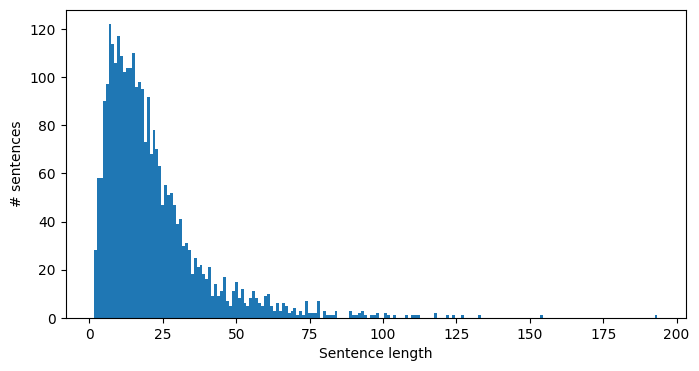

In [6]:
l = np.asarray([len(x) for x in X], dtype=int)
plt.figure(figsize=(8, 4))
x = np.unique(l)
plt.bar(x, [np.sum(l==e) for e in x], width=1)
plt.xlabel("Sentence length")
plt.ylabel("# sentences")
plt.show()

## Data encoding and padding

In [7]:
tokens = {token for sentence in X_train for token in sentence}
idx2token = list(tokens)
idx2token.insert(0, '<UNK>')
idx2token.append('<PAD>')
token2idx = {token:idx for idx, token in enumerate(idx2token)}

tags = {tag for tags in y_train for tag in tags}
idx2tag = list(tags)
idx2tag.append('<PAD>')
tag2idx = {tag:idx for idx, tag in enumerate(idx2tag)}

print(idx2token[:15])
print(idx2tag)

['<UNK>', 'เรียลลิตี้โชว์', '51', 'ช้ำ', 'เรียบง่าย', 'ศรีย่าน', 'ฆ่า', 'ประจำ', 'culture', 'จีนแคะ', 'วิธี', 'จีรนันท์', 'พรม', '56.75', 'ปารานา']
['PROPN', 'CCONJ', 'AUX', 'PART', 'SYM', 'DET', 'ADP', 'SCONJ', 'NUM', 'PRON', 'ADJ', 'NOUN', 'VERB', 'PUNCT', 'ADV', '<PAD>']


In [13]:
def pad_and_encode(batch):
  sentences, labels = zip(*batch)
  assert len(sentences)==len(labels)
  assert np.all([len(sentence)==len(tags) for sentence, tags in zip(sentences, labels)])
  max_sentence_length = np.max([len(sentence) for sentence in sentences]) # Find out how much to pad
  padded_sentences = torch.zeros(len(sentences), max_sentence_length,     # Create data structures with <PAD> as default
                                 dtype=torch.long)
  padded_sentences[:] = token2idx['<PAD>']
  padded_labels = torch.zeros(len(sentences), max_sentence_length,
                              dtype=torch.long)
  padded_labels[:] = tag2idx['<PAD>']
  for i, (sentence, tags) in enumerate(zip(sentences, labels)):               # Loop over the data
    for j, token in enumerate(sentence):
      if token in token2idx:
        padded_sentences[i, j] = token2idx[token]
      else:
        padded_sentences[i, j] = token2idx['<UNK>']
    for j, tag in enumerate(tags):
      padded_labels[i, j] = tag2idx[tag]
  return padded_sentences, padded_labels

In [14]:
from torch.utils.data import Dataset, DataLoader

class UDDataset(Dataset):
    """UD dataset."""

    def __init__(self, X, y):
        """
        Arguments:
            X (list): List of token sequences
            y (list): List of tag sequences
        """
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        
        return self.X[idx], self.y[idx]

dataset = UDDataset(X_train, y_train)

In [16]:
import os
import multiprocessing as mp
mp.set_start_method("fork", force=True)                                       # från äldre python för linux fork subprocesser

cores = os.cpu_count()
print(f"All your {cores} CPU cores are belong to us. HA HA HA HA...")

cats = DataLoader(dataset, batch_size=5,                                      # https://platform.theverge.com/wp-content/uploads/sites/2/chorus/uploads/chorus_asset/file/23666725/SEGA_Genesis___June_2022_Game_Updates___Nintendo_Switch_Online_0_29_screenshot.png?quality=90&strip=all&crop=0,1.6437308868502,100,96.7125382263
                        shuffle=False, 
                        num_workers=cores, 
                        persistent_workers=True,                              # gör att man kan köra multiprocessing i en ipynb cell utan pickle error
                        collate_fn=pad_and_encode                             # har ändrat arg i pad_and_encode så att det passar med dataset-batch
)

print("Take off every 'Zig!")

batch_iterator = iter(cats)
next(batch_iterator)

All your 12 CPU cores are belong to us. HA HA HA HA...
Take off every 'Zig!


(tensor([[4550,  948, 3938,  827, 2215, 3467, 5375, 1871, 2419, 2558, 3746,  816,
           132, 4037, 4440, 4254, 1594, 4254, 1140, 3285, 4440, 5221, 3657, 5470,
          5470, 5470, 5470, 5470],
         [4440, 1653,   97, 2322, 1699, 1520, 4136, 3938, 3384, 3624, 4998, 2322,
          5227,   97, 1923, 2162, 4992, 5470, 5470, 5470, 5470, 5470, 5470, 5470,
          5470, 5470, 5470, 5470],
         [3804, 3993, 5470, 5470, 5470, 5470, 5470, 5470, 5470, 5470, 5470, 5470,
          5470, 5470, 5470, 5470, 5470, 5470, 5470, 5470, 5470, 5470, 5470, 5470,
          5470, 5470, 5470, 5470],
         [1533, 4872, 3457, 3639, 1789, 2167, 3507, 2558, 5436, 3120, 4123, 3624,
          5091, 3712,  851, 1271, 4254, 2334, 2947, 4440, 4924, 5279, 5470, 5470,
          5470, 5470, 5470, 5470],
         [4254, 1360, 2558, 2668,  986, 3821, 3624,  189, 1791, 4822, 4214, 3938,
          4699, 3467, 3492, 4335, 2118, 2558, 2126,  183, 2302, 3938, 4699, 3509,
          2795, 1578,  337, 1648]]),
 te

## Model

In [17]:
class LSTMTagger(nn.Module):
  def __init__(self, word_embedding_dim, lstm_hidden_dim, vocabulary_size, tagset_size, bidirectional=True):
    """An LSTM based tagger

    word_embedding_dim
      The dimensionality of the word embedding
    lstm_hidden_dim
      The dimensionality of the hidden state in the LSTM
    vocabulary_size
      The number of unique tokens in the word embedding (including <PAD> etc)
    tagset_size
      The number of unique POS tags (not including <PAD>, as we don't want to predict it)
    """
    super(LSTMTagger, self).__init__()                                          # We need to initialise the class we are inheriting from
    self.lstm_hidden_dim_ = lstm_hidden_dim                                     # This simply stores the parameters
    self.vocabulary_size_ = vocabulary_size
    self.tagset_size_ = tagset_size

    self._word_embedding = nn.Embedding(num_embeddings=vocabulary_size,         # Creates the vector space for the input words
                                         embedding_dim=word_embedding_dim,
                                         padding_idx=token2idx['<PAD>'])
    self._lstm = nn.LSTM(input_size=word_embedding_dim,                         # The LSTM takes an embedded sentence as input, and outputs
                         hidden_size=lstm_hidden_dim,                           # vectors with dimensionality lstm_hidden_dim.
                         batch_first=True, 
                         bidirectional=bidirectional)                           # output: (N, L, D*H) = (batch_size, sequence_length, D*hidden_size) where D is 2 if bidirectional=True, else 1
                                                                                # source: https://docs.pytorch.org/docs/stable/generated/torch.nn.LSTM.html
    self._gru = nn.GRU(input_size=word_embedding_dim,                
                       hidden_size=lstm_hidden_dim,                           
                       batch_first=True,
                       bidirectional=bidirectional)                       
    if bidirectional:
      self._fc = nn.Linear(lstm_hidden_dim*2, tagset_size)                      # NB times 2 because of bidirectional LSTM
    else:
      self._fc = nn.Linear(lstm_hidden_dim, tagset_size)
    self._softmax = nn.LogSoftmax(dim=1)                                        # Softmax of outputting PDFs over tags

    self.training_loss_ = list()                                                # For plotting
    self.training_accuracy_ = list()

    if torch.cuda.is_available():                                               # Move the model to the GPU (if we have one)
      self.cuda()

  def forward(self, padded_sentences):
    """The forward pass through the network"""
    batch_size, max_sentence_length = padded_sentences.size()

    embedded_sentences = self._word_embedding(padded_sentences)                 # Sentences encoded as integers are mapped to vectors

    sentence_lengths = (padded_sentences!=token2idx['<PAD>']).sum(dim=1)        # Find the length of sentences
    sentence_lengths = sentence_lengths.long().cpu()                            # Ensure the correct format
    X = nn.utils.rnn.pack_padded_sequence(embedded_sentences, sentence_lengths, # Pack the embedded data
                                          batch_first=True, enforce_sorted=False)
    lstm_out, _ = self._lstm(X)                                                 # Run the LSTM layer
    X, _ = nn.utils.rnn.pad_packed_sequence(lstm_out, batch_first=True)         # Unpack the output from the LSTM

    X = X.contiguous().view(-1, X.shape[2])                                     # .shape[2] because the hidden state is the third dim of the LSTM output
    tag_space = self._fc(X)                                                     # Fully connected layer
    tag_scores = self._softmax(tag_space)                                       # Softmax is applied to normalise the outputs
    return tag_scores.view(batch_size, max_sentence_length, self.tagset_size_)


model = LSTMTagger(word_embedding_dim=32,                                       # Dimensionality of the work embedding
                   lstm_hidden_dim=64,                                          # Dimensionality of the hidden state in the LSTM
                   vocabulary_size=len(token2idx),                              # The vocabulary incudes both the 'padding' and 'unknown' symbols
                   tagset_size=len(tag2idx)-1)                                  # We have no interest in the network outputting the padding symbol
print(model)

LSTMTagger(
  (_word_embedding): Embedding(5471, 32, padding_idx=5470)
  (_lstm): LSTM(32, 64, batch_first=True, bidirectional=True)
  (_gru): GRU(32, 64, batch_first=True, bidirectional=True)
  (_fc): Linear(in_features=128, out_features=15, bias=True)
  (_softmax): LogSoftmax(dim=1)
)


## Network training

In [ ]:
loss_function = nn.NLLLoss(ignore_index=tag2idx['<PAD>'])                       # NLLLoss = Negative Log Likelihood Loss.
                                                                                # The loss function will ignore the padding index in the targets.
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)                       # We give the optimiser the parameters to work with, note that we can choose to only give some parameters

batch_size = 256                                                                # Define the size of each batch
for epoch in range(5):                                                          # Times to loop over the full dataset
  with tqdm(batch_iterator(X_train, y_train, batch_size=batch_size),
            total=len(X_train)//batch_size+1, unit="batch", desc="Epoch %i" % epoch) as batches:
    for inputs, targets in batches:                                             # Loop once over the training data
      model.zero_grad()                                                         # Reset gradients
      scores = model(inputs)                                                    # Forward pass
      loss = loss_function(scores.view(-1, model.tagset_size_),                 # Get loss, the data is reshaped as a long line of predictions and targets
                           targets.view(-1))
      loss.backward()                                                           # Backpropagate the error
      optimizer.step()                                                          # Run the optimizer to change the weights w.r.t the loss
      predictions = scores.argmax(dim=2, keepdim=True).squeeze()                # Calculate the batch training accuracy
      mask = targets!=tag2idx['<PAD>']                                          # Create a mask for ignoring <PAD> in the targets
      correct = (predictions[mask] == targets[mask]).sum().item()               # Item pulls the value from the GPU automatically (if needed)
      accuracy = correct / mask.sum().item()*100
      model.training_accuracy_.append(accuracy)                                 # Save the accuracy for plotting
      model.training_loss_.append(loss.item())                                  # Save the loss for plotting
      batches.set_postfix(loss=loss.item(), accuracy=accuracy)                  # Update the progress bar

Epoch 4: 100%|██████████| 11/11 [00:04<00:00,  2.59batch/s, accuracy=88.5, loss=0.367]


We can plot the stored loss over epochs.

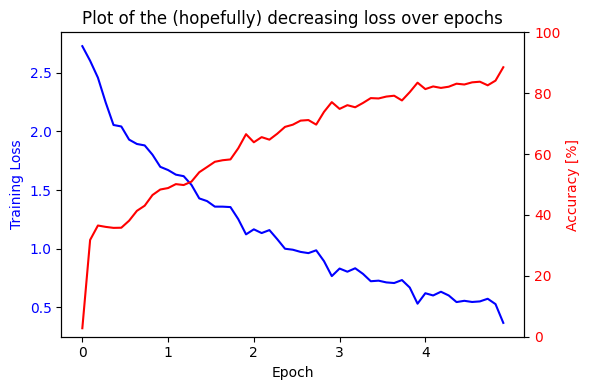

In [14]:
fig = plt.figure(figsize=(6, 4))
ax = plt.subplot()
ax.set_title("Plot of the (hopefully) decreasing loss over epochs")
ax.plot(model.training_loss_, 'b-')
ax.set_ylabel("Training Loss", color='b')
ax.set_xlabel("Epoch")
# ax.set_yscale('log')
ax.tick_params(axis='y', labelcolor='b')
ax = ax.twinx()
ax.plot(model.training_accuracy_, 'r-')
ax.set_ylabel("Accuracy [%]", color='r')
ax.tick_params(axis='y', labelcolor='r')
a = list(ax.axis())
a[2] = 0
a[3] = 100
ax.axis(a)
t = np.arange(0, len(model.training_accuracy_), len(X_train)//batch_size+1)
ax.set_xticks(ticks=t)
ax.set_xticklabels(labels=np.arange(len(t)))
fig.tight_layout()
plt.show()

## Test data accuracy

This shows that the model sort of works. A per sentence accuracy would be better while being able to also analyse the predictions qualitatively would be best.

In [15]:
with torch.no_grad():                                                           # Do not use the following forward passes to calculate a gradient
  n_correct = 0
  n_total = 0
  for inputs, targets in batch_iterator(X_test, y_test, batch_size=batch_size): # Loop once over the test data
    scores = model(inputs)                                                      # Runs the test data through the model
    predictions = scores.argmax(dim=2, keepdim=True).squeeze()                  # Finds the predictions
    mask = targets!=tag2idx['<PAD>']                                            # Create a mask for ignoring <PAD> in the targets
    n_correct += (predictions[mask] == targets[mask]).sum().item()              # Sums the number of correct predictions
    n_total += mask.sum().item()
print("Test accuracy %.1f%%" % (100*n_correct/n_total))

Test accuracy 81.8%
